# Name - Swatej Sonawane
# Github Username - swatejsonawane18
# USC ID - 9314761761

Note - 1 Grace day used for this assignment

References - 

https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
https://imbalanced-learn.org/stable/generated/imblearn.pipeline.Pipeline.html
https://stackoverflow.com/questions/58815016/cross-validating-with-imblearn-pipeline-and-gridsearchcv
http://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html
https://towardsdatascience.com/k-means-clustering-from-a-to-z-f6242a314e9a

In [1]:
import sys
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedShuffleSplit,KFold
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC,LinearSVC
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.metrics import accuracy_score,classification_report, silhouette_samples,silhouette_score,hamming_loss
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform, cdist
import warnings
import statistics
import random

# Q1 a

In [2]:
data = pd.read_csv(r'../data/Anuran Calls (MFCCs)/Frogs_MFCCs.csv')
x = data.iloc[:,:-4]
y = data.loc[:,['Family','Genus','Species']]
print(y.columns)

print(data)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,shuffle=True)


Index(['Family', 'Genus', 'Species'], dtype='object')
      MFCCs_ 1  MFCCs_ 2  MFCCs_ 3  MFCCs_ 4  MFCCs_ 5  MFCCs_ 6  MFCCs_ 7  \
0          1.0  0.152936 -0.105586  0.200722  0.317201  0.260764  0.100945   
1          1.0  0.171534 -0.098975  0.268425  0.338672  0.268353  0.060835   
2          1.0  0.152317 -0.082973  0.287128  0.276014  0.189867  0.008714   
3          1.0  0.224392  0.118985  0.329432  0.372088  0.361005  0.015501   
4          1.0  0.087817 -0.068345  0.306967  0.330923  0.249144  0.006884   
...        ...       ...       ...       ...       ...       ...       ...   
7190       1.0 -0.554504 -0.337717  0.035533  0.034511  0.443451  0.093889   
7191       1.0 -0.517273 -0.370574  0.030673  0.068097  0.402890  0.096628   
7192       1.0 -0.582557 -0.343237  0.029468  0.064179  0.385596  0.114905   
7193       1.0 -0.519497 -0.307553 -0.004922  0.072865  0.377131  0.086866   
7194       1.0 -0.508833 -0.324106  0.062068  0.078211  0.397188  0.094596   

      MFC

# Q1 b i

In multi-label classification, the performance of a classifier can be evaluated using various metrics, such as exact match and Hamming score/loss.

Exact Match (EM):
The exact match score measures the proportion of instances where the predicted labels exactly match the true labels. This metric is calculated by dividing the number of instances where the predicted labels exactly match the true labels by the total number of instances in the dataset. The EM score ranges from 0 to 1, with 1 indicating perfect performance.

Hamming score/loss:
The Hamming score/loss measures the similarity between the predicted and true labels, by comparing the number of labels that are correctly predicted with the total number of labels across all instances. The Hamming score is calculated as the ratio of the number of correctly predicted labels to the total number of labels, while the Hamming loss is the complement of the Hamming score, i.e., 1 - Hamming score. The Hamming score/loss ranges from 0 to 1, with 1 indicating perfect performance.

In [20]:
pipeline_svc = Pipeline([('clf', OneVsRestClassifier(SVC(gamma='auto'), n_jobs=-1)),])
for c in y_train.columns:
    pipeline_svc.fit(x_train,y_train[c])
    y_pred_test = pipeline_svc.predict(x_test)
    print(f'Test accuracy for considering {c} as target class = {accuracy_score(y_test[c],y_pred_test)}')
    print(f'Hamming loss for considering {c} as target class = {hamming_loss(y_test[c],y_pred_test)}\n')

Test accuracy for considering Family as target class = 0.7642427049559981
Hamming loss for considering Family as target class = 0.23575729504400186

Test accuracy for considering Genus as target class = 0.7165354330708661
Hamming loss for considering Genus as target class = 0.28346456692913385

Test accuracy for considering Species as target class = 0.6415006947660954
Hamming loss for considering Species as target class = 0.3584993052339046



# Q1 b ii

In [28]:
warnings.filterwarnings(action='ignore')
y_pred = pd.DataFrame()
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
C_range = np.logspace(-2, 2, 5)
gamma_range = np.logspace(-2, 2, 5)
param_grid = dict(gamma=gamma_range, C=C_range)
cv = KFold(n_splits=10)
for c in y_train.columns:
    grid = GridSearchCV(SVC(kernel='rbf',decision_function_shape='ovr'),param_grid=param_grid,cv=cv)
    grid.fit(x_train,y_train[[c]])
    y_pred[c] = model.predict(x_test)
    print(f'The best parameters considering {c} as the target label are: %s with a score of %0.2f'%(grid.best_params_,grid.best_score_))
    print(f'Hamming loss for considering {c} as target class = {hamming_loss(y_test[[c]].values.ravel(), y_pred[c])}\n')

The best parameters considering Family as the target label are: {'C': 10.0, 'gamma': 0.1} with a score of 0.99
Hamming loss for considering Family as target class = 1.0

The best parameters considering Genus as the target label are: {'C': 10.0, 'gamma': 0.01} with a score of 0.99
Hamming loss for considering Genus as target class = 1.0

The best parameters considering Species as the target label are: {'C': 10.0, 'gamma': 0.01} with a score of 0.99
Hamming loss for considering Species as target class = 1.0



# Q1 b iii

In [29]:
warnings.filterwarnings(action='ignore')
y_pred_l1 = pd.DataFrame()
C_range = np.logspace(-2, 2, 5)
params = dict(C=C_range)
cv = KFold(n_splits=10)
for c in y_train.columns:
    gs_cv = GridSearchCV(LinearSVC(penalty='l1',loss='squared_hinge',multi_class='ovr',dual=False),param_grid=params,cv=cv)
    ##x_train is standardized from previous run.
    gs_cv.fit(x_train,y_train[c])
    y_pred_l1[c] = gs_cv.predict(x_test)
    print(f'The best parameters considering {c} as the target label are: %s with a score of %0.2f'%(gs_cv.best_params_,gs_cv.best_score_))
    print(f'Hamming loss for considering {c} as target class = {hamming_loss(y_test[[c]].values.ravel(), y_pred_l1[c])}\n')

The best parameters considering Family as the target label are: {'C': 10.0} with a score of 0.93
Hamming loss for considering Family as target class = 0.3788791106993979

The best parameters considering Genus as the target label are: {'C': 100.0} with a score of 0.95
Hamming loss for considering Genus as target class = 0.4006484483557202

The best parameters considering Species as the target label are: {'C': 1.0} with a score of 0.96
Hamming loss for considering Species as target class = 0.4089856415006948



# Q1 b iv

In [30]:
smote = SMOTE()
warnings.filterwarnings(action='ignore')
y_pred_smote = pd.DataFrame()
C_range = np.logspace(-2, 2, 5)
params = dict(C=C_range)
cv = KFold(n_splits=10)
for c in y_train.columns:
    #x_train is standardized from previous run.
    x_train_resample, y_train_resample = smote.fit_resample(x_train,y_train[c])
    gs_cv_smote = GridSearchCV(LinearSVC(penalty='l1',loss='squared_hinge',multi_class='ovr',dual=False),param_grid=params,cv=cv)
    gs_cv_smote.fit(x_train_resample,y_train_resample)
    y_pred_smote[c] = gs_cv_smote.predict(x_test)
    print(f'The best parameters considering {c} as the target label are: %s with a score of %0.2f'%(gs_cv_smote.best_params_,gs_cv_smote.best_score_))
    print(f'Hamming loss for considering {c} as target class = {hamming_loss(y_test[[c]].values.ravel(), y_pred_smote[c])}\n')

The best parameters considering Family as the target label are: {'C': 10.0} with a score of 0.94
Hamming loss for considering Family as target class = 0.9170912459471978

The best parameters considering Genus as the target label are: {'C': 100.0} with a score of 0.92
Hamming loss for considering Genus as target class = 0.32607688744789254

The best parameters considering Species as the target label are: {'C': 100.0} with a score of 0.88
Hamming loss for considering Species as target class = 0.7401574803149606



# Q2

In [9]:
family={p:[] for p in range(1,51)}
genus={p:[] for p in range(1,51)}
species={p:[] for p in range(1,51)}
random_int = random.randint(0,700)
ham_loss = []
ham_score = []

In [9]:
K = range(2, 50)
hamming_losses = []
hamming_score = []
hamming_distance = []

data = pd.read_csv(r'../data/Anuran Calls (MFCCs)/Frogs_MFCCs.csv')
x = data.iloc[:, :-4]
labels = ['Family', 'Genus', 'Species']

for iterNo in range(50):
    print(f'\n\nIteration {iterNo+1}')
    
    # selecting best k
    silhs = []
    resultantLabels = []
    for k in K:
        kmeans = KMeans(n_clusters = k, random_state = random.randint(1, 1000000)).fit(x)
        label = kmeans.labels_
        resultantLabels.append(label)
        silhs.append(silhouette_score(x, label))
    i = np.argmax(silhs)
    best_labels = resultantLabels[i]
    best_k = i + 2
    print('The best value of K is', best_k)
    
    # majority labels
    labels_data = data[labels].copy()
    labels_data['label_km'] = best_labels
    majority_label = {}
    for l in range(best_k):
        majority_triplet = {}
        clst = labels_data[labels_data['label_km'] == l]
        for tl in labels:
            majority_triplet[tl] = clst[tl].value_counts().idxmax()
        majority_label[l] = majority_triplet
    
    # compute hamming loss, hamming score, and hamming dist
    misclassifed_loss = 0
    for l in range(best_k):
        clst = labels_data[labels_data['label_km'] == l]
        for tl in labels:
            tmp = sum(clst[tl] != majority_label[l][tl])
            misclassifed_loss += tmp
    
    hamming_loss1 = misclassifed_loss / (len(data) * 3)
    hamming_losses.append(hamming_loss1)
    hamming_score.append(1 - hamming_loss1)
    hd = misclassifed_loss / len(data)
    hamming_distance.append(hd)
    
    print("Majority labels:", majority_label)
    print(f'Hamming loss = {hamming_loss1}')
    print(f'Hamming score = {1 - hamming_loss1}')
    print(f'Hamming distance = {hd}')

print('\n\n\n')
print('Average of Hamming Loss', np.mean(hamming_losses))
print('Average of Hamming score', np.mean(hamming_score))
print('Average of Hamming dist', np.mean(hamming_distance))
print('Std Deviation of Hamming Distance', np.std(hamming_distance))



Iteration 1
The best value of K is 4
Majority labels: {0: {'Family': 'Hylidae', 'Genus': 'Hypsiboas', 'Species': 'HypsiboasCinerascens'}, 1: {'Family': 'Leptodactylidae', 'Genus': 'Adenomera', 'Species': 'AdenomeraHylaedactylus'}, 2: {'Family': 'Hylidae', 'Genus': 'Hypsiboas', 'Species': 'HypsiboasCordobae'}, 3: {'Family': 'Dendrobatidae', 'Genus': 'Ameerega', 'Species': 'Ameeregatrivittata'}}
Hamming loss = 0.2224229789205467
Hamming score = 0.7775770210794533
Hamming distance = 0.66726893676164


Iteration 2
The best value of K is 4
Majority labels: {0: {'Family': 'Hylidae', 'Genus': 'Hypsiboas', 'Species': 'HypsiboasCinerascens'}, 1: {'Family': 'Leptodactylidae', 'Genus': 'Adenomera', 'Species': 'AdenomeraHylaedactylus'}, 2: {'Family': 'Hylidae', 'Genus': 'Hypsiboas', 'Species': 'HypsiboasCordobae'}, 3: {'Family': 'Dendrobatidae', 'Genus': 'Ameerega', 'Species': 'Ameeregatrivittata'}}
Hamming loss = 0.2224229789205467
Hamming score = 0.7775770210794533
Hamming distance = 0.6672689

The best value of K is 4
Majority labels: {0: {'Family': 'Dendrobatidae', 'Genus': 'Ameerega', 'Species': 'Ameeregatrivittata'}, 1: {'Family': 'Hylidae', 'Genus': 'Hypsiboas', 'Species': 'HypsiboasCordobae'}, 2: {'Family': 'Leptodactylidae', 'Genus': 'Adenomera', 'Species': 'AdenomeraHylaedactylus'}, 3: {'Family': 'Hylidae', 'Genus': 'Hypsiboas', 'Species': 'HypsiboasCinerascens'}}
Hamming loss = 0.2224229789205467
Hamming score = 0.7775770210794533
Hamming distance = 0.66726893676164


Iteration 19
The best value of K is 4
Majority labels: {0: {'Family': 'Dendrobatidae', 'Genus': 'Ameerega', 'Species': 'Ameeregatrivittata'}, 1: {'Family': 'Leptodactylidae', 'Genus': 'Adenomera', 'Species': 'AdenomeraHylaedactylus'}, 2: {'Family': 'Hylidae', 'Genus': 'Hypsiboas', 'Species': 'HypsiboasCinerascens'}, 3: {'Family': 'Hylidae', 'Genus': 'Hypsiboas', 'Species': 'HypsiboasCordobae'}}
Hamming loss = 0.22214500810748206
Hamming score = 0.7778549918925179
Hamming distance = 0.6664350243224462




The best value of K is 4
Majority labels: {0: {'Family': 'Hylidae', 'Genus': 'Hypsiboas', 'Species': 'HypsiboasCordobae'}, 1: {'Family': 'Hylidae', 'Genus': 'Hypsiboas', 'Species': 'HypsiboasCinerascens'}, 2: {'Family': 'Leptodactylidae', 'Genus': 'Adenomera', 'Species': 'AdenomeraHylaedactylus'}, 3: {'Family': 'Dendrobatidae', 'Genus': 'Ameerega', 'Species': 'Ameeregatrivittata'}}
Hamming loss = 0.2224229789205467
Hamming score = 0.7775770210794533
Hamming distance = 0.66726893676164


Iteration 36
The best value of K is 4
Majority labels: {0: {'Family': 'Hylidae', 'Genus': 'Hypsiboas', 'Species': 'HypsiboasCordobae'}, 1: {'Family': 'Leptodactylidae', 'Genus': 'Adenomera', 'Species': 'AdenomeraHylaedactylus'}, 2: {'Family': 'Dendrobatidae', 'Genus': 'Ameerega', 'Species': 'Ameeregatrivittata'}, 3: {'Family': 'Hylidae', 'Genus': 'Hypsiboas', 'Species': 'HypsiboasCinerascens'}}
Hamming loss = 0.2224229789205467
Hamming score = 0.7775770210794533
Hamming distance = 0.66726893676164


Ite

# Q3

a - On the basis of this dissimilarity matrix, sketch the dendrogram
that results from hierarchically clustering these four observa-
tions using complete linkage. Be sure to indicate on the plot the
height at which each fusion occurs, as well as the observations
corresponding to each leaf in the dendrogram.

[0.3  0.4  0.7  0.5  0.8  0.45]
[[0.   1.   0.3  2.  ]
 [2.   3.   0.45 2.  ]
 [4.   5.   0.8  4.  ]]


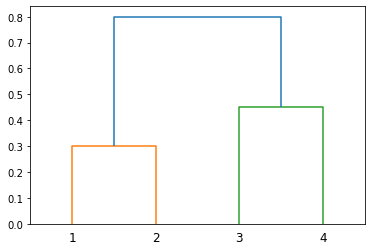

In [13]:
distance_matrix = np.array([
    [0.0, 0.3, 0.4, 0.7], 
    [0.3, 0.0, 0.5, 0.8], 
    [0.4, 0.5, 0.0, 0.45], 
    [0.7, 0.8, 0.45, 0.0]
])
distance = squareform(distance_matrix)
print(distance)
complete_linkage_matrix = linkage(distance, "complete")
print(complete_linkage_matrix)
dendrogram(complete_linkage_matrix, labels=["1", "2", "3", "4"])
plt.show()

b - Repeat (a), this time using single linkage clustering.

[[0.   1.   0.3  2.  ]
 [2.   4.   0.4  3.  ]
 [3.   5.   0.45 4.  ]]


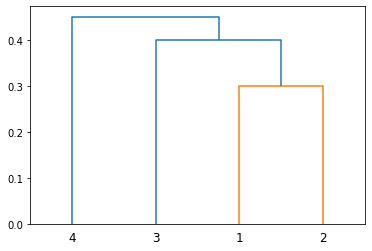

In [16]:
single_linkage_matrix = linkage(distance, "single")
print(single_linkage_matrix)
dendrogram(single_linkage_matrix, labels=["1", "2", "3", "4"])
plt.show()

c - Suppose that we cut the dendrogram obtained in (a) such that
two clusters result. Which observations are in each cluster?

Cluster A - Observation 1, 2 <br>
Cluster B - Observation 3, 4



d - Suppose that we cut the dendrogram obtained in (b) such that
two clusters result. Which observations are in each cluster?

Cluster A - Observation (1, 2), 3 <br>
Cluster B - Observation 4

e - It is mentioned in the chapter that at each fusion in the den-
drogram, the position of the two clusters being fused can be
swapped without changing the meaning of the dendrogram. Draw
a dendrogram that is equivalent to the dendrogram in (a), for
which two or more of the leaves are repositioned, but for which
the meaning of the dendrogram is the same.

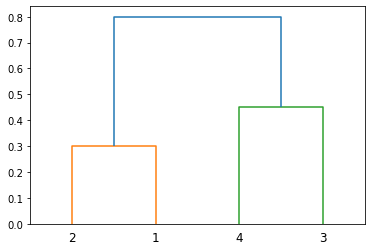

In [18]:
distance = squareform(distance_matrix)
complete_linkage_matrix_swap = linkage(distance, "complete")
dendrogram(complete_linkage_matrix_swap, labels=["2", "1", "4", "3"])
plt.show()